# Student Heath Risk EDA

### **Problem Statement & Competition Objective**

* **Context:** Modern college students experience complex interactions between daily habits, physiological metrics, and stress factors that impact their overall health.
* **Objective:** Build a multi-class classification model to predict a student's **`health_condition`** into one of three risk tiers:
    * **`fit`**: Healthy & balanced condition
    * **`at-risk`**: Moderate health concerns (Majority class)
    * **`unhealthy`**: High health risk


* **Evaluation Metric:** **Balanced Accuracy** — treats all three classes equally, penalizing models that favor the majority class (`at-risk`).

### Imports

In [1]:
import numpy as np
import pandas as pd
import os
import kagglehub
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [3]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## Data Understanding

#### **Dataset Overview & Structure**

* **Dataset Origin:** Synthetically generated dataset modeled after large-scale college student health studies, blending survey data, wearable device logs, and health records.
* **Feature Breakdown:**
    * **Numerical (Physiological & Wearable Logs):** `sleep_duration`, `heart_rate`, `bmi`, `calorie_expenditure`, `step_count`, `exercise_duration`, and `water_intake`.
    * **Categorical (Behavioral & Psychological):** `diet_type`, `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, and `gender`.


* **Synthetic Data Characteristics:** Modeled on real-world distributions, but contains synthetic artifacts (such as boundary spikes, zero-inflation mass, and multimodal distribution patterns) that offer distinct feature engineering opportunities.

In [4]:
df.shape

(690088, 15)

In [5]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [6]:
quantative = df.select_dtypes(['number']).columns.to_list()
qualitative = df.select_dtypes(['object']).columns.to_list()
qualitative.remove('health_condition')
quantative.remove("id")

print(f"Quantative: {quantative},\n Qualitative: {qualitative}")

Quantative: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake'],
 Qualitative: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [7]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [8]:
for col in qualitative:
    print(df[col].value_counts(),'\n')

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64 

stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64 

sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64 

physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64 

smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64 

gender
male      237756
female    224016
other     206943
Name: count, dtype: int64 



**Categorical Feature Strategy:**
* **Low Cardinality:** Every qualitative feature (`diet_type`, `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, `gender`) contains exactly **3 unique categories**.
* **Encoding Plan:** Standard One-Hot Encoding (OHE) is lightweight and well-suited. However, ordered features (e.g., `stress_level`, `sleep_quality`) can also be tested with **Ordinal Encoding** to preserve feature hierarchy.

### Datatype Converstion

In [9]:
df = df.set_index("id")
df[qualitative] = df[qualitative].astype("category")
df['health_condition'] = df['health_condition'].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   health_condition         690088 non-null  category
 1   sleep_duration           614089 non-null  float64 
 2   heart_rate               682255 non-null  float64 
 3   bmi                      676190 non-null  float64 
 4   calorie_expenditure      637235 non-null  float64 
 5   step_count               676172 non-null  float64 
 6   exercise_duration        683187 non-null  float64 
 7   water_intake             646611 non-null  float64 
 8   diet_type                683187 non-null  category
 9   stress_level             607277 non-null  category
 10  sleep_quality            631757 non-null  category
 11  physical_activity_level  653467 non-null  category
 12  smoking_alcohol          661506 non-null  category
 13  gender                   668715 non-null  categor

# Exploratory Data Analysis 

## Missing Values

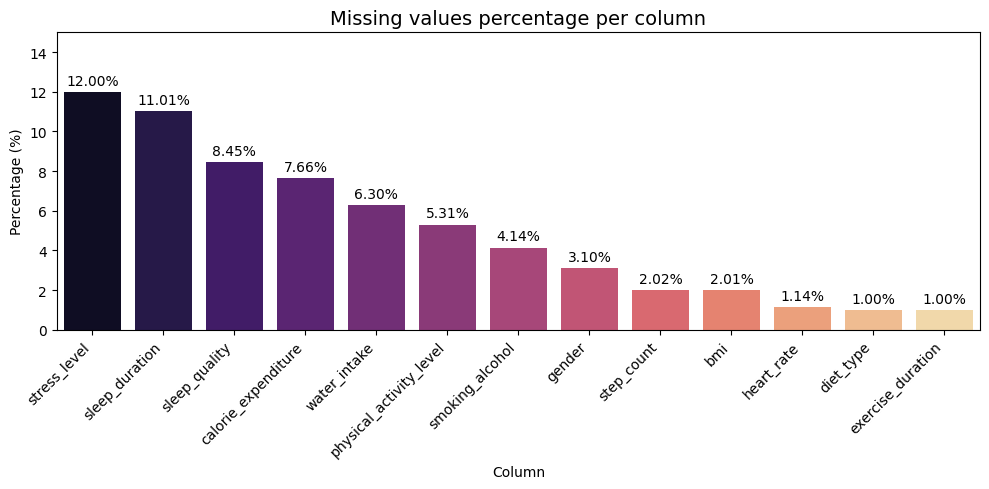

In [10]:
missing_col = df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)
missing_df = (( missing_col / df.shape[0]) * 100).reset_index()
missing_df.columns = ['Column', 'Missing_Percentage']

plt.figure(figsize=(10,5))
ax = sns.barplot(data=missing_df, x="Column", y='Missing_Percentage', palette='magma', hue='Column')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Missing values percentage per column", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.ylim(0, missing_df['Missing_Percentage'].max() + 3)
plt.tight_layout()

plt.show()

#### Testing Hypothesis

**Hypothesis (H1):** Missing values in `exercise_duration` might represent zero minutes of exercise. 

In [11]:
df[['health_condition']][df['exercise_duration'].isna()].value_counts(normalize=True)

health_condition
at-risk             0.850891
unhealthy           0.088683
fit                 0.060426
Name: proportion, dtype: float64

In [12]:
df[['health_condition']][df['exercise_duration'].notna()].value_counts(normalize=True)

health_condition
at-risk             0.858753
unhealthy           0.083596
fit                 0.057650
Name: proportion, dtype: float64

### Missing Values Co-ocurance:

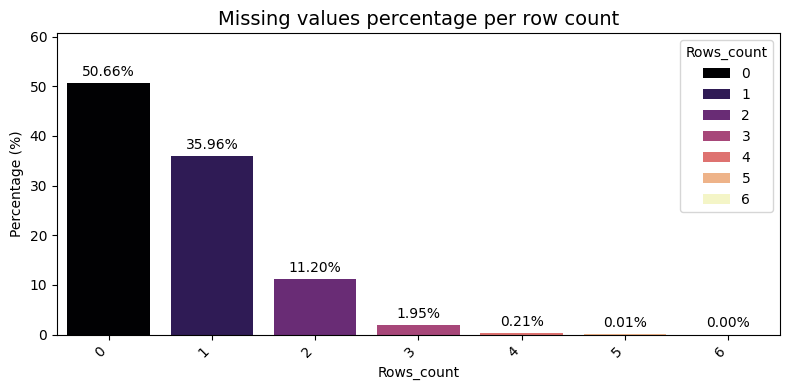

In [13]:
missing_values_rows = df.isna().sum(axis=1).value_counts()
missing_row_df = ((missing_values_rows / df.shape[0]) * 100).reset_index()

missing_row_df = (( missing_values_rows / df.shape[0]) * 100).reset_index()
missing_row_df.columns = ['Rows_count', 'Missing_Percentage']

plt.figure(figsize=(8,4))
ax = sns.barplot(data=missing_row_df, x="Rows_count", y='Missing_Percentage', palette='magma', hue='Rows_count')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Missing values percentage per row count", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.ylim(0, missing_row_df['Missing_Percentage'].max() + 10)
plt.tight_layout()

plt.show()

### Duplicate Rows 

In [14]:
# Check duplicates across all columns except 'id'
df.duplicated(subset=df.columns.difference(['id'])).sum()

np.int64(0)

### Missing Value Distribution Across Target Classes

#### Objective & Motivation

Because the competition evaluation metric is `balanced_accuracy`, each target class (at-risk, unhealthy, fit) contributes equally to the final score regardless of class size.

If missing feature values were concentrated heavily in minority classes (fit or unhealthy), improper imputation could disproportionately harm prediction quality for those classes and significantly drag down the overall balanced accuracy score.

In [15]:
records = []

for col in missing_df["Column"]:
    for health_class in df["health_condition"].dropna().unique():
        class_total = (df["health_condition"] == health_class).sum() 
        class_missing = (
            df[df[col].isna()]['health_condition']
            .value_counts()
            .get(health_class,0)
        )

        records.append(
            {
                "Column": col,
                "health_condition": health_class,
                "Class_missing_pct": (class_missing/class_total) * 100,
            }
        )
missing_class_norm = pd.DataFrame(records)
missing_class_norm.groupby('health_condition').agg({"Class_missing_pct":'sum'})

,Class_missing_pct
health_condition,
at-risk,65.215733
fit,65.733739
unhealthy,63.905828


#### **Key Findings**

* **Class-Normalized Analysis:** To account for the severe class imbalance (~85% `at-risk` vs. ~6% `fit`), we calculated the **within-class missing rate** for each feature:

$$\text{Class Missing Rate (\%)} = \frac{\text{Missing rows in Column } X \text{ with Class } C}{\text{Total rows in Class } C} \times 100$$


* **Uniform Missingness Pattern:** Across all features, the total missingness rate remains nearly identical across target classes:
* **`at-risk`**: ~65.2%
* **`fit`**: ~65.7%
* **`unhealthy`**: ~63.9%


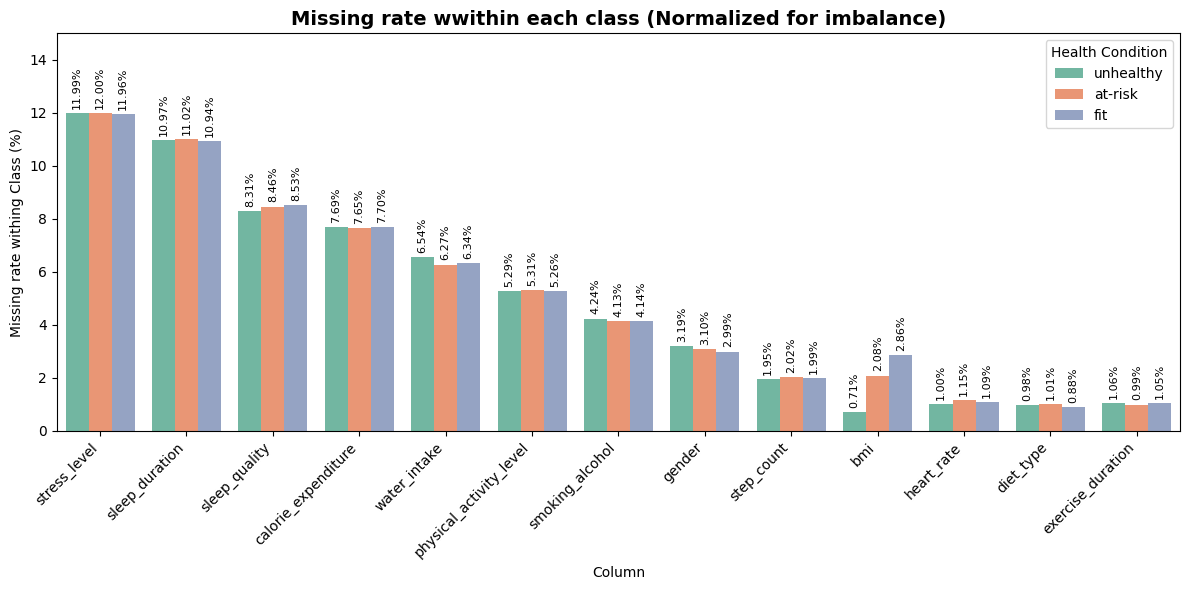

In [16]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=missing_class_norm,
    x='Column',
    y='Class_missing_pct',
    hue='health_condition',
    palette='Set2',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=8, rotation=90)

plt.title("Missing rate wwithin each class (Normalized for imbalance)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Missing rate withing Class (%)")
plt.ylim(0, missing_class_norm['Class_missing_pct'].max() + 3)
plt.legend(title="Health Condition")
plt.tight_layout()
plt.show()

In [17]:
test['bmi'].isna().sum() / test.shape[0]

np.float64(0.020138426321964612)

**Key Insight (`bmi` Anomaly):**
 * **Non-Random Pattern:** Unlike other features, `bmi` missingness varies heavily by class missing values are ~4x more likely to be fit than unhealthy.

* **Significant Signal:** Affecting ~14k rows in `train` and ~2% of `test`, this gap is too large to be random noise.


* **Action:** Create an indicator feature (`bmi_is_missing`) prior to imputation to preserve this predictive signal for the model.


#### **Summary of Missing Data Findings & Strategy**

* **Hypothesis Disproved (H1):** Missing values in `exercise_duration` do **not** represent zero minutes of exercise. The distribution of `health_condition` is virtually identical across both missing (`~85.1% at-risk, ~8.9% unhealthy, ~6.0% fit`) and non-missing groups `(~85.9% at-risk, ~8.4% unhealthy, ~5.8% fit)`.

* **Uniform Distribution (MCAR):** Across nearly all features, missingness is **Missing Completely at Random**, showing identical class distributions (~85% at-risk, ~8.5% unhealthy, ~6% fit).
* **Row-Level Breakdown:** ~50% of rows are completely clean, ~47% have only 1–2 missing values, and only ~3% have >2 missing values.
* **`bmi` Predictive Signal:** `bmi` is the sole exception—missingness varies significantly by class (~4x more frequent in `fit`). We will create a binary `bmi_is_missing` indicator feature prior to imputation to keep this signal.
* **Imputation Strategy:** Because missingness does not favor any target class, standard imputation will not bias `balanced_accuracy` against minority classes. We will compare **Simple (Mean/Median)** vs. **Advanced (KNN)** imputation methods to optimize performance.



## Target Analysis

### Evaluation Metric 

**Balanced Accuracy Metric**

* **Equal Class Weight:** Calculates the average recall across each class individually, treating majority (`at-risk`) and minority classes (`unhealthy`, `fit`) with equal importance.
* **Handles Imbalance:** Unlike standard accuracy, it penalizes models that ignore minority classes just to achieve a high score on the majority class.
* **Benchmark Range:** Ranges from **33.3%** ($0.33$) for a naive baseline model predicting a single class to **100%** ($1.0$) for a perfect classifier.

$$\text{Balanced Accuracy} = \frac{\text{Recall}_{\text{at-risk}} + \text{Recall}_{\text{unhealthy}} + \text{Recall}_{\text{fit}}}{3} $$

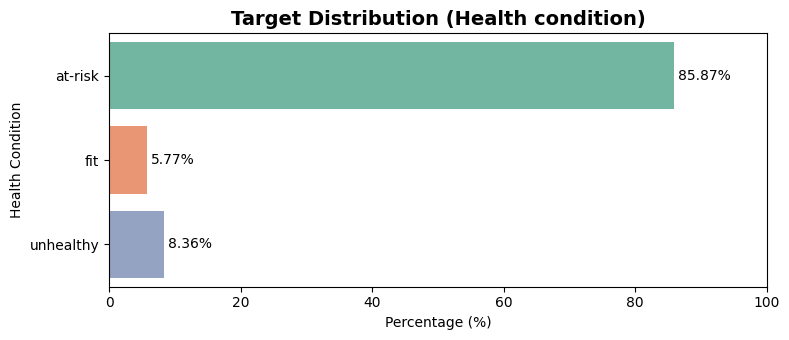

In [18]:
target_pct = (df['health_condition'].value_counts(normalize=True) * 100).reset_index()
target_pct.columns = ['health_condition', 'percentage']

plt.figure(figsize=(8,3.5))
ax = sns.barplot(
    data=target_pct,
    y='health_condition',
    x='percentage',
    palette="Set2",
    hue='health_condition',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Target Distribution (Health condition)", fontsize=14, fontweight='bold')
plt.xlabel("Percentage (%)")
plt.ylabel("Health Condition")
plt.xlim(0,100)
plt.tight_layout()
plt.show()

#### **Target Class Imbalance & Metric Impact**

* **Severe Class Imbalance:** The target variable (`health_condition`) has an extreme class distribution of roughly **85 : 9 : 6**:
    * **`at-risk`**: ~85.3% (Majority)
    * **`unhealthy`**: ~8.8% (Minority)
    * **`fit`**: ~5.8% (Minority)


* **Why Accuracy is Misleading:**
A naive baseline model predicting `at-risk` 100% of the time would achieve a high standard accuracy of **~85%**, despite completely failing to identify any healthy or unhealthy students.

* **The Power of `balanced_accuracy`:**
Because the competition evaluates on **`balanced_accuracy`**, each class contributes equally. That same dummy model yields a score of **only 33.3% ($0.33$)**

* **Modeling Strategy:** Standard accuracy will be a false indicator of progress. Models must focus on minority class recall through class weighting, threshold adjustment, or resampling techniques to maximize balanced accuracy.

#### **Key Strategy Insights**

* **Class-Normalized EDA (Imbalance vs. Scarcity):**
This is a **class imbalance problem, not a data scarcity problem** (~40k–60k rows exist for minority classes). All feature plots must be class-normalized ($P(\text{feature} \mid \text{class})$) or target-rate binned so the ~85% `at-risk` majority doesn't mask minority patterns.

* **Minority Separation & Ordinal Structure:**
Since `fit` and `unhealthy` carry two-thirds ($66.7\%$) of the `balanced_accuracy` metric, EDA must focus strictly on features that separate `fit` from `unhealthy`. Additionally, the target has a natural ordinal severity scale ($\text{fit} \rightarrow \text{at-risk} \rightarrow \text{unhealthy}$), serving as a key modeling lever.

## Numerical - Univariate Analysis

In [19]:
quantative

['sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'step_count',
 'exercise_duration',
 'water_intake']

In [20]:
num_df = df[quantative].melt()

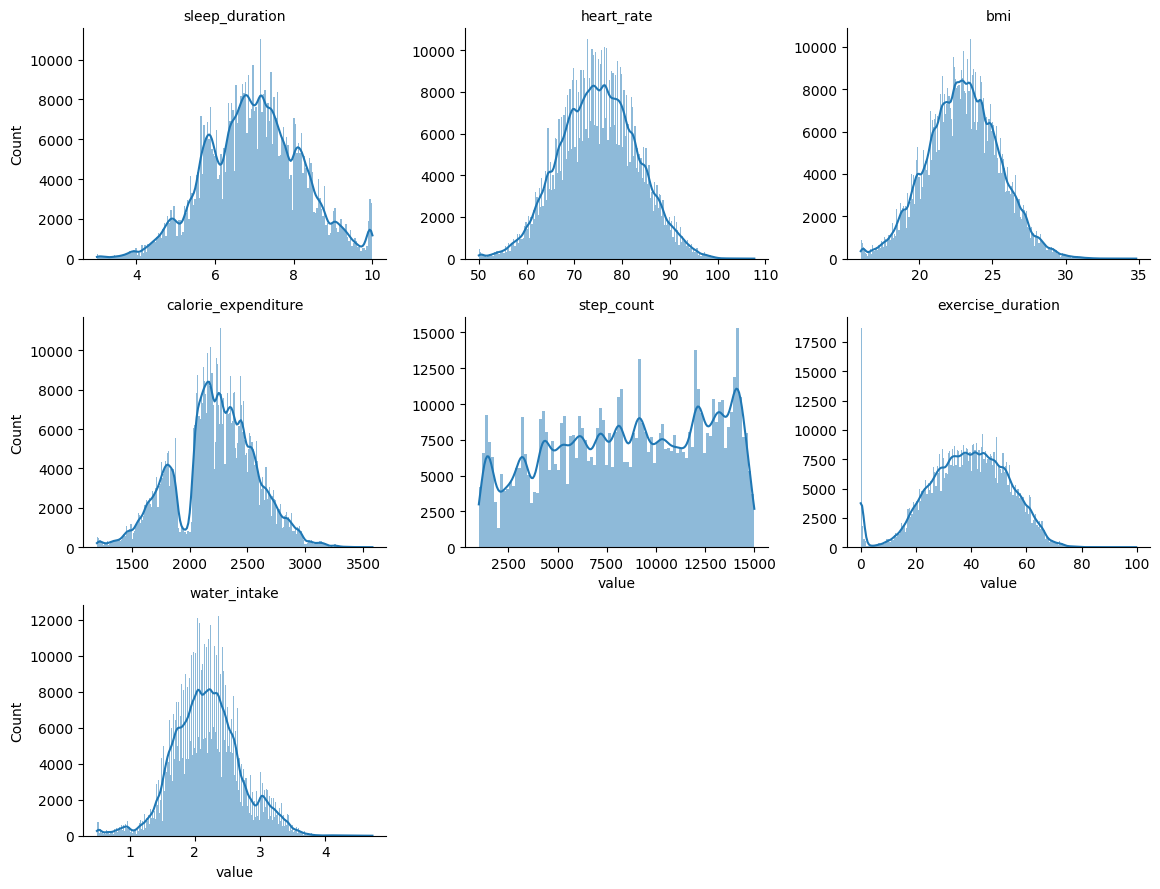

In [21]:
g = sns.displot(
    data=num_df,
    x='value',
    col='variable',
    col_wrap=3,
    kind='hist',
    kde=True,
    common_bins=False,
    facet_kws={'sharex': False, 'sharey': False},
    height=3,
    aspect=1.3
)

g.set_titles(col_template="{col_name}")
plt.show()

#### Univariate Analysis Insights

* `heart_rate` & `bmi` (near-normal & skewed):
    * `heart_rate` follows a near-perfect bell curve centered around `~75 bpm`.
    * `bmi` is unimodal centered around `~23`, exhibiting a moderate right tail extending up to `35`.


* `calorie_expenditure` has a bimodal distribution and exhibits two distinct clusters: a minor peak near `~1,700 kcal` and a major peak near `~2,250 kcal`, separated by a sharp drop at `~1,900 kcal`.


* `step_count` has a multi-spike / comb pattern distribution and displays a highly multimodal, comb-like distribution with regularly spaced sharp spikes across the `2,000–15,000` step range—a classic signature of synthetic data generation.


* `sleep_duration` & `water_intake` (bounded & mode-centered): `sleep_duration` concentrates heavily in the `6–8 hour` range with boundary spikes visible at `10 hours`, while `water_intake` is right-skewed, peaking sharply between `2.0–2.5 L/day`.

* `exercise_duration` (zero-inflation & boundary artifacts): While non-zero values follow a smooth normal curve centered around `~40 mins`, there is a massive point mass (spike) at `0 minutes`.

## Numerical - Bivariate Analysis

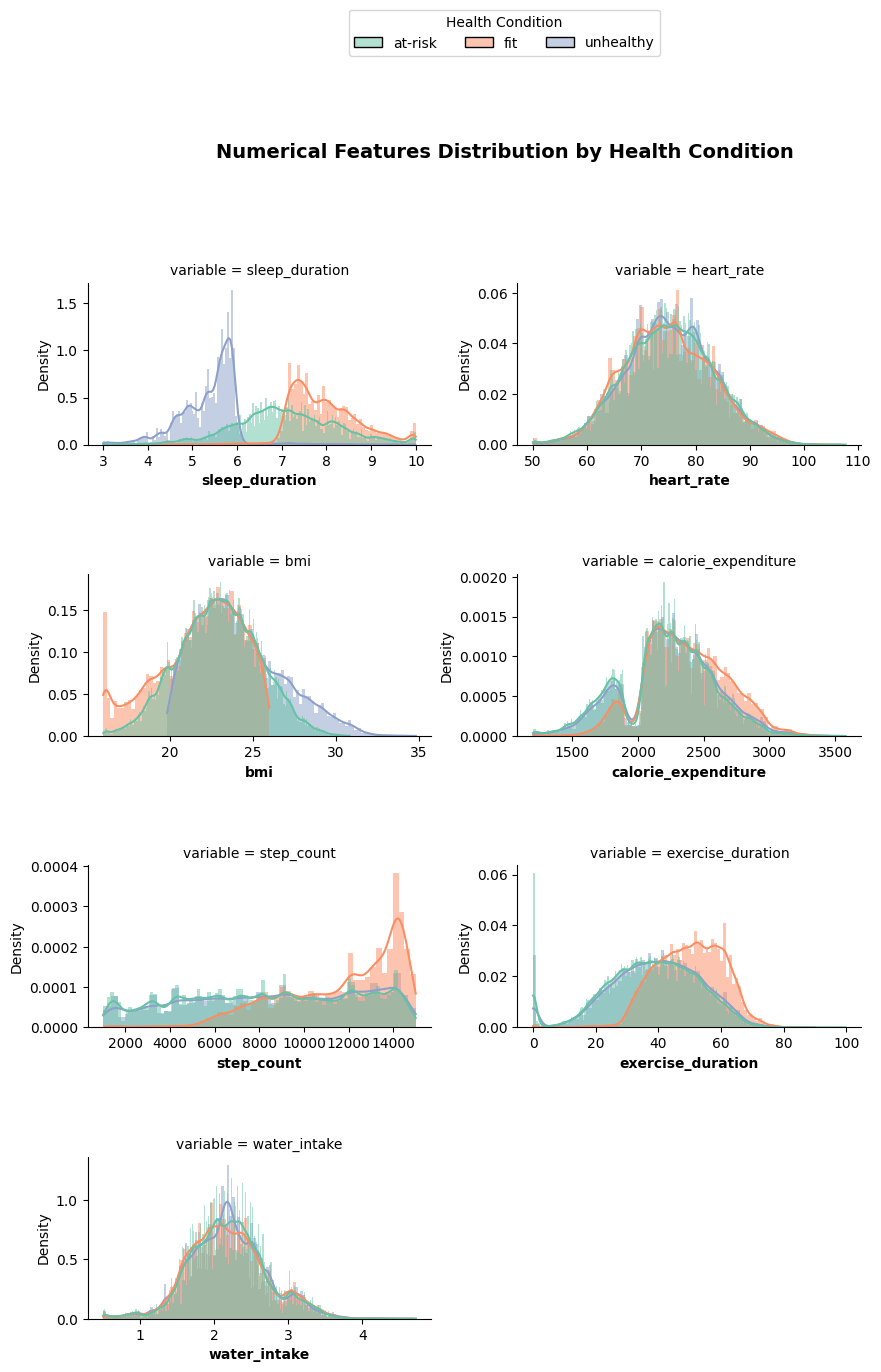

In [22]:
num_bivar_df = df[quantative + ["health_condition"]].melt(id_vars="health_condition")

g = sns.displot(
    data=num_bivar_df,
    x="value",
    hue="health_condition",
    col="variable",
    col_wrap=2,
    kind="hist",
    kde=True,
    common_bins=False,
    stat="density",
    common_norm=False,
    facet_kws={"sharex":False,"sharey":False},
    height=3.5,
    aspect=1.3,
    palette="Set2"
)

for ax, col_name in zip(g.axes.flat, num_bivar_df["variable"].unique()):
    ax.set_xlabel(col_name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Density", fontsize=10)

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    title="Health Condition",
    frameon=True,
)

plt.subplots_adjust(top=0.82, bottom=0.08, hspace=0.8, wspace=0.25)
g.fig.suptitle("Numerical Features Distribution by Health Condition", fontsize=14, fontweight="bold", y=0.92)
plt.show()

Here is the updated text with all references changed to `fit` students:

#### Bivariate Analysis Insights

* `sleep_duration` shows the strongest, near-perfect ordinal separation across classes: `unhealthy` peaks lowest (`~5.2h`), `at-risk` sits in the middle (`~6.9h`), and `fit` reaches highest (`~7.8h`).

* `exercise_duration` & `step_count` reveal that `fit` students shift noticeably toward higher values (more exercise/steps), while `at-risk` and `unhealthy` distributions heavily overlap.

* `bmi` exhibits a strong right-skewed separation where `unhealthy` students dominate the higher BMI range (>26), while `fit` students concentrate on the lower, fitter BMI side (<22).

* `calorie_expenditure` shows a bimodal structure where `fit` students shift toward the higher expenditure peak (`~2,400+ kcal`), whereas `unhealthy` students lean toward lower caloric burn (`~1,700 kcal`).

* `heart_rate` & `water_intake` show virtually identical distributions across all three health conditions, providing almost no clear linear separation on their own.


**The checklist**

1. ~**Target** — classes, balance, what each class means, the metric.~
2. **Shape & dtypes** — rows, cols, numeric vs categorical, cardinality, duplicates.
3. **Missingness** — done. (Add: missing-vs-target rate.)
4. **Baseline** — submit it. Now you have a number to beat.
5. **Numerical** — univariate (dist, skew, spikes at 0/999), then vs target (bin the feature, plot target rate per bin), then correlation.
6. **Categorical** — cardinality, rare levels, target rate per level, levels in test not in train.
7. **Train vs test drift** — same distributions? Synthetic data sometimes shifts.
8. **Write 5 hypotheses** — carry into part 2.
